In [16]:
import pandas as pd
import sqlite3

In [17]:
conn = sqlite3.connect('data/checking-logs.sqlite')

In [18]:
checker = pd.io.sql.read_sql(
    "SELECT timestamp FROM checker WHERE uid LIKE 'user_%'",
    conn,
    parse_dates=['timestamp']
)
checker

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [19]:
def get_daytime(hour):
    if 0 <= hour <= 3:
        return 'night'
    elif 4 <= hour <= 9:
        return 'morning'
    elif 10 <= hour <= 16:
        return 'afternoon'
    else:
        return 'evening'

checker['date'] = checker['timestamp'].dt.date
checker['daytime'] = checker['timestamp'].dt.hour.apply(get_daytime)
checker

,timestamp,date,daytime
0,2020-04-17 05:19:02.744528,2020-04-17,morning
1,2020-04-17 05:22:35.249331,2020-04-17,morning
2,2020-04-17 05:22:45.549397,2020-04-17,morning
3,2020-04-17 05:34:14.691200,2020-04-17,morning
4,2020-04-17 05:34:24.422370,2020-04-17,morning
...,...,...,...
3202,2020-05-21 20:19:06.872761,2020-05-21,evening
3203,2020-05-21 20:22:41.785725,2020-05-21,evening
3204,2020-05-21 20:22:41.877806,2020-05-21,evening
3205,2020-05-21 20:37:00.129678,2020-05-21,evening


In [20]:
commits_by_daytime = checker.groupby(['date', 'daytime']).size().reset_index(name='commits')
commits_pivot = commits_by_daytime.pivot(index='date', columns='daytime', values='commits').fillna(0)
commits_pivot = commits_pivot[['night', 'morning', 'afternoon', 'evening']]
commits_pivot

daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0.0,13.0,10.0,0.0
2020-04-18,0.0,1.0,33.0,35.0
2020-04-19,2.0,4.0,16.0,11.0
2020-04-20,0.0,0.0,12.0,13.0
2020-04-21,0.0,0.0,0.0,25.0
2020-04-22,0.0,0.0,4.0,24.0
2020-04-23,2.0,6.0,15.0,20.0
2020-04-24,0.0,0.0,4.0,12.0
2020-04-25,1.0,21.0,33.0,49.0


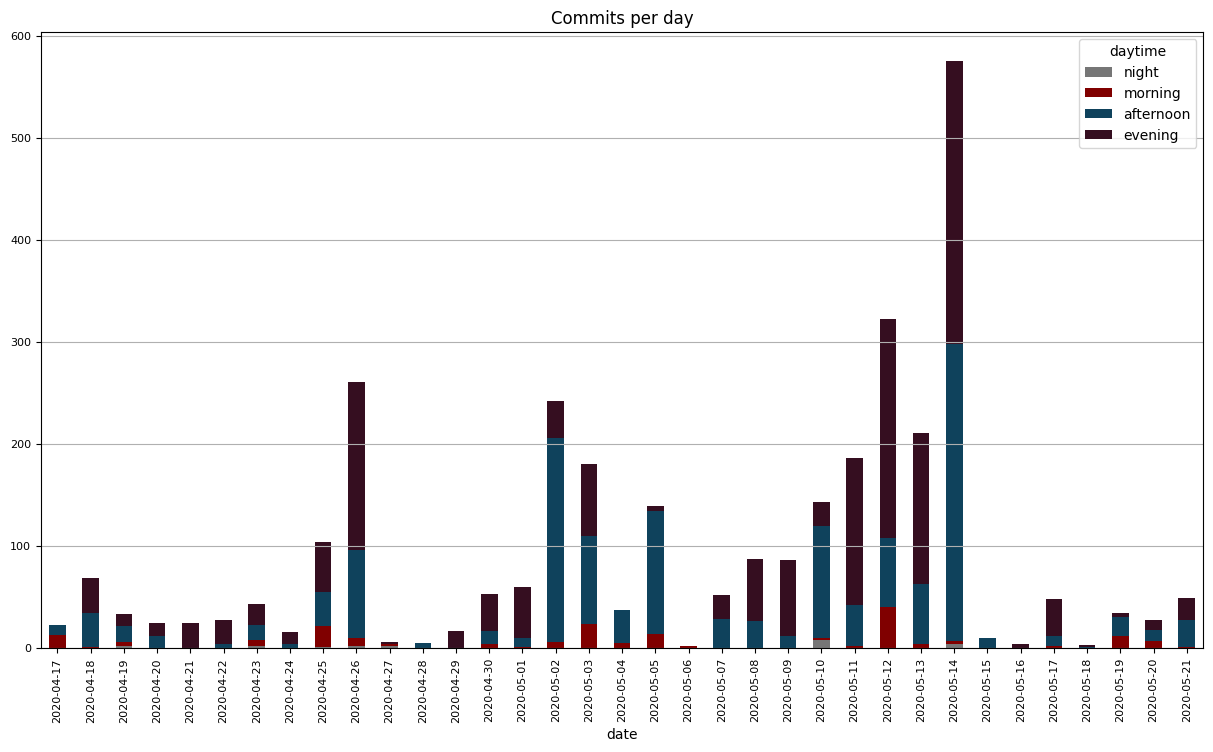

In [21]:
commits_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 8),
    fontsize=8,
    title='Commits per day',
    rot=90,
    color=['#767676FF', '#800000FF', '#0F425CFF', '#350E20FF']
).grid(axis='y')

In [22]:
conn.close()

Когда пользователи обычно коммитят лабораторные: ночью, утром, днем или вечером?

Ответ: **днем и вечером**

В какой день было больше всего коммитов и при этом коммитов вечером было больше чем днем?

Ответ: **2020-05-12**